# 1️⃣What are Metrics in Scikit-learn?

Metrics = Tools to measure how good or bad your machine learning model is performing.

After training the model → we check predictions vs actual values → metrics help us judge accuracy, error, precision, recall, etc.

In [ ]:
from sklearn.metrics import accuracy_score, r2_score, mean_absolute_error, mean_squared_error, confusion_matrix, classification_report

# 2️⃣ Types of Metrics (based on model type)

| Type of Model      | Common Metrics                                          |
| ------------------ | ------------------------------------------------------- |
| **Regression**     | MAE, MSE, RMSE, R² Score                                |
| **Classification** | Accuracy, Precision, Recall, F1-score, Confusion Matrix







| Metric                                      | Formula / Meaning                                               | Lower/ Higher Better  |
| ------------------------------------------- | --------------------------------------------------------------- | --------------------- |
| **MAE (Mean Absolute Error)**               | Average absolute difference between predicted and actual values | Lower is better       |
| **MSE (Mean Squared Error)**                | Square of differences (penalizes large errors)                  | Lower is better       |
| **R² Score (Coefficient of Determination)** | Explains how much variance is captured by model                 | Closer to 1 is better |



# 1️⃣ What is Mean Absolute Error (MAE)?

MAE = Average of absolute differences between actual values and predicted values.

It tells how far on average the model’s predictions are from the actual results.

Formula:

MAE=1/n ∑ |y-y_pred|

y=actual value
y_pred=predicted value
n=total number of samples
||=absoulte value(always positive)



Let’s say we are predicting house prices.

| Sample | Actual (y) | Predicted (ŷ) | Error (y - ŷ) | Absolute Error |
| :----: | :--------: | :-----------: | :-----------: | :------------: |
|    1   |     100    |       90      |       10      |       10       |
|    2   |     200    |      220      |      -20      |       20       |
|    3   |     300    |      280      |       20      |       20       |
|    4   |     400    |      390      |       10      |       10       |



MAE=10+20+20+10/4= 60/4 =>15

✅ Mean Absolute Error = 15

On average, the model’s prediction is off by 15 units (e.g., ₹15K if house prices in thousands).



=> When to Use MAE?

Use MAE when:

You want equal weight to all errors (large/small).

Outliers (extreme values) are not too important.

Example: Predicting marks, sales, or price where small errors okay.

In [3]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

y=[100,200,300,400]
y_pred=[90,220,280,390]


print(mean_absolute_error(y,y_pred))


15.0


# 2️⃣ What is Mean Squared Error (MSE)?


MSE (Mean Squared Error) is the average of squared differences between actual values and predicted values.

It measures how much the predictions deviate from the actual values,
but it gives more penalty to larger errors (since errors are squared).


Formula:

MSE=1/n ∑ (y-y_pred)square

y=actual value
y_pred=predicted value
n=no. of samples



Let’s say we are predicting marks of students based on hours studied:

| Sample | Actual (y) | Predicted (y_pred) | Error (y - y_pred) | Squared Error |
| :----: | :--------: | :-----------: | :-----------: | :-----------: |
|    1   |     50     |       45      |       5       |       25      |
|    2   |     60     |       55      |       5       |       25      |
|    3   |     70     |       65      |       5       |       25      |
|    4   |     90     |       75      |       15      |      225      |



Now sum the squared errors:

MSE=25+25+25+225/4=300/4=>75

Mean Squared Error = 75


MSE tells us how much the predicted values differ from actual values,
on average (in squared units).

Since errors are squared, big mistakes are penalized heavily.

Example:

Error = 2 → squared = 4

Error = 10 → squared = 100 ❗ (Large penalty)


When to Use MSE

✅ Use MSE when:

You want to penalize large errors more

You’re training models using Gradient Descent (smooth loss function)

Outliers matter a lot (since they increase MSE strongly)

❌ Avoid MSE when:

Outliers are not important → Use MAE instead

In [4]:
from sklearn.metrics import mean_squared_error

y=[50,60,70,90]
y_pred=[45,55,65,75]

mse=mean_squared_error(y,y_pred)
print("Mean Squared Error:",mse)

Mean Squared Error: 75.0


# 3️⃣ R² Score


R² (R-squared) batata hai ki aapka model kitna achha actual data ko explain kar raha hai.
It measures how well your regression model fits the data.

👉 In simple words:

“R² batata hai model ne data ke variation ka kitna part sahi predict kiya.”


Bhai soch, tu ek teacher hai,
aur tere students ke exam marks predict karne wala ek model banaya hai.

Ab R² ye batata hai:

“Tera model ne students ke marks kitne sahi guess kiye hain.”


To model ka guess almost sahi hai na?

To R² bolega — “Wah! Tumhara model bahut accha kaam kar raha hai!”
Aur usko ek number de dega jaise 0 se 1 tak.


2. Formula
R(square)=1-ss(res)/ss(tot)

ss(res)=∑(y-y^_pred)(square)==>Residual Sum of Squares (Error)
ss(tot)=∑(y-y_pred)(square)==>Total Sum of Squares (Total Variation)



1.Total Variance (SS_tot) — ye batata hai data kitna spread hai mean ke around.
(Jaise student marks 10 se 90 tak hai → variance zyada)

2.Residual Variance (SS_res) — ye batata hai model ne kitna error kiya (actual vs predicted difference).

3.Ratio ss(res)/ss(tot) batata hai model ne kitana variance miss kiya.

4. 1 - ratio batata hai model ne kitna variance sahi explain kiya.


=> Example Calculation


| Actual (y) | Predicted (ŷ) |
| ---------- | ------------- |
| 3          | 2.5           |
| 5          | 5.5           |
| 7          | 6.5           |


step-1 mean of y=>(3+5+7)/3=5

Step 2: SS_tot=>(3-5)square+(5-5)square+(7-5)square=4+0+4=8

Step 3: SS_res=>(3−2.5)2+(5−5.5)2+(7−6.5)2=0.25+0.25+0.25=0.75

Step 4: R²=>1−(0.75/8)=1−0.09375=0.90625

✅ R² = 0.91 → Model explains 91% of data variation. Excellent!





R² Score Interpretation=>

| R² Value | Meaning                                  |
| -------- | ---------------------------------------- |
| 1.0      | Perfect fit (model predicts exactly)     |
| 0.9      | 90% variance explained — Excellent       |
| 0.5      | 50% variance explained — Average         |
| 0.0      | Model as good as mean prediction         |
| < 0.0    | Model is worse than just predicting mean |





In [1]:
from sklearn.metrics import r2_score

y_true = [3, 5, 7]
y_pred = [2.5, 5.5, 6.5]

r2 = r2_score(y_true, y_pred)
print("R² Score:", r2)


R² Score: 0.90625


# Classification model metrices->


1️⃣ Confusion Matrix — Base of Everything

Soch bhai ek doctor hai jo predict karta hai patient ko disease hai ya nahi.


| Actual / Predicted  | Disease (Yes)         | No Disease (No)       |
| ------------------- | --------------------- | --------------------- |
| **Disease (Yes)**   | ✅ True Positive (TP)  | ❌ False Negative (FN) |
| **No Disease (No)** | ❌ False Positive (FP) | ✅ True Negative (TN)  |



| Word                    | Meaning                                             |
| ----------------------- | --------------------------------------------------- |
| **True Positive (TP)**  | Model ne sahi bola “disease hai”                    |
| **True Negative (TN)**  | Model ne sahi bola “disease nahi hai”               |
| **False Positive (FP)** | Model ne galat bola “disease hai” (jab nahi thi)    |
| **False Negative (FN)** | Model ne galat bola “disease nahi hai” (jab thi 😨) |


In [4]:
from sklearn.metrics import confusion_matrix

y=[1, 0, 1, 1, 0, 0, 1]
y_pred=[1, 0, 0, 1, 0, 1, 1]


cm = confusion_matrix(y, y_pred)
print(cm)


# [[2 1]   # TN, FP
#  [1 3]]  # FN, TP


[[2 1]
 [1 3]]


# 2️⃣ Accuracy – Kitna sahi bola overall

Model ne total predictions me se kitni baar sahi bola?

accuracy=TP+TN/TP+TN+FP+FN


Example:

Out of 100 patients, 90 sahi predict kiye →
👉 Accuracy = 90/100 = 0.9 or 90%

🟢 Good jab dono classes (Yes/No) balanced ho.

⚠️ Problem: Agar 95% log healthy hain, model har kisi ko “Healthy” bole to bhi accuracy 95% aayegi — but wrong.

In [5]:
from sklearn.metrics import accuracy_score


y_true = [1, 0, 1, 1, 0, 0, 1]
y_pred = [1, 0, 0, 1, 0, 1, 1]

print(accuracy_score(y_true,y_pred))

0.7142857142857143


# 3️⃣ Precision – “Disease bola” to kitni baar sahi bola

Jab model bole “Yes”, tab kitni baar wo sach me “Yes” tha?


Precision=TP/TP+FP

Example:

Model ne 10 logon ko “disease hai” bola,
jisme se 8 ko sach me thi →
Precision = 8/10 = 0.8 (80%)

🟢 High Precision → model galat “Yes” kam bolta hai

💡 Use: Spam detection (ham mail ko spam mat bolo!)

In [6]:
from sklearn.metrics import precision_score


y_true = [1, 0, 1, 1, 0, 0, 1]
y_pred = [1, 0, 0, 1, 0, 1, 1]

print(precision_score(y_true,y_pred))

0.75


# 4️⃣ Recall – Jitno ko disease thi, unme kitno ko pakda

Model ne total “disease wale” me se kitno ko sahi pakda?


Recall=TP/TP+FN


Example:

10 logon ko disease thi,
model ne 8 pakde aur 2 chhode →
Recall = 8/10 = 0.8 (80%)

🟢 High Recall → model miss kam karta hai.

💡 Use: Disease detection (kisi patient ko miss mat karo!)

In [7]:
from sklearn.metrics import  recall_score

y_true = [1, 0, 1, 1, 0, 0, 1]
y_pred = [1, 0, 0, 1, 0, 1, 1]


print("Recall:", recall_score(y_true, y_pred))


Recall: 0.75


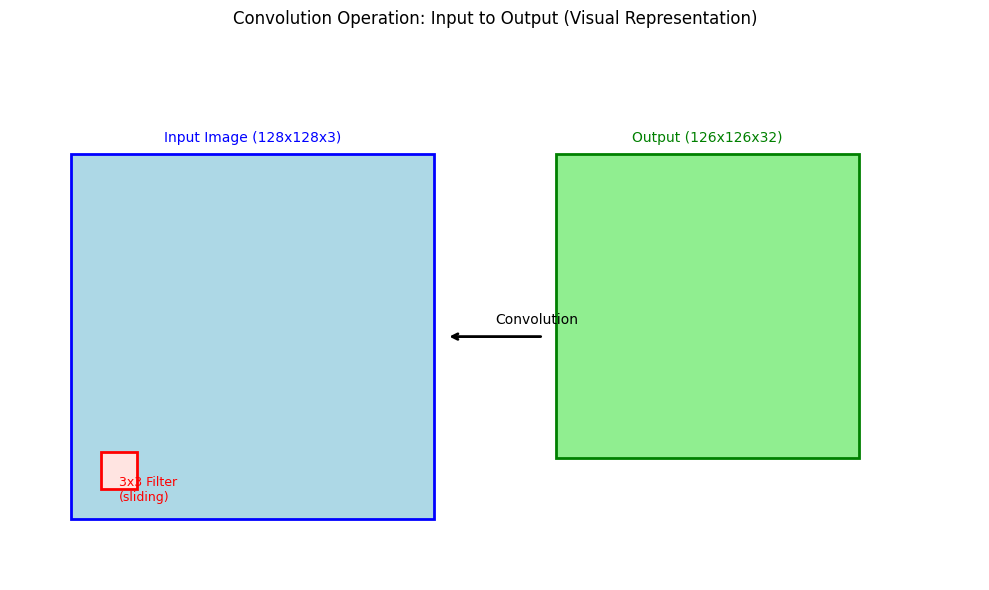

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Image dimensions
input_size = 128
filter_size = 3
stride = 1
output_size = (input_size - filter_size) // stride + 1

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Input Image Box
input_rect = patches.Rectangle((0, 0), 6, 6, linewidth=2, edgecolor='blue', facecolor='lightblue')
ax.add_patch(input_rect)
ax.text(3, 6.2, 'Input Image (128x128x3)', ha='center', fontsize=10, color='blue')

# Filter Box (on input image)
filter_rect = patches.Rectangle((0.5, 0.5), 0.6, 0.6, linewidth=2, edgecolor='red', facecolor='mistyrose')
ax.add_patch(filter_rect)
ax.text(0.8, 0.3, '3x3 Filter\n(sliding)', fontsize=9, color='red')

# Output Feature Map Box
output_rect = patches.Rectangle((8, 1), 5, 5, linewidth=2, edgecolor='green', facecolor='lightgreen')
ax.add_patch(output_rect)
ax.text(10.5, 6.2, 'Output (126x126x32)', ha='center', fontsize=10, color='green')

# Arrow from input to output
ax.annotate('', xy=(6.2, 3), xytext=(7.8, 3), arrowprops=dict(arrowstyle='->', lw=2))
ax.text(7, 3.2, "Convolution", fontsize=10)

# Aesthetics
ax.set_xlim(-1, 15)
ax.set_ylim(-1, 8)
ax.axis('off')
plt.title("Convolution Operation: Input to Output (Visual Representation)", fontsize=12)
plt.tight_layout()
plt.show()


# 5️⃣ F1-Score – Precision aur Recall ka Balance


Jab Precision aur Recall dono important ho, unka average nikalte hain.

F1=2*(Precision*Recall)/(Precision+Recall)


Example:

Precision = 0.8, Recall = 0.8
F1 = 2 × (0.8×0.8) / (0.8+0.8) = 0.8

🟢 Perfect Balance = 1
⚪ Poor Balance = 0

💡 Use: Jab data unbalanced ho (spam emails, fraud cases, etc.)

In [ ]:
from sklearn.metrics import  f1_score

y_true = [1, 0, 1, 1, 0, 0, 1]
y_pred = [1, 0, 0, 1, 0, 1, 1]


print("F1-Score:", f1_score(y_true, y_pred))


# In short:

Confusion Matrix = Base Table

Accuracy = Overall score

Precision = Kitne sahi “Yes” bole

Recall = Kitne “Yes” pakde

F1 = Balance of both 


| Scenario            | What’s Important                          |
| ------------------- | ----------------------------------------- |
| Spam mail detection | **Precision** (ham mail ko spam mat bolo) |
| Disease detection   | **Recall** (patient miss mat karo)        |
| Balanced dataset    | **Accuracy**                              |
| Unbalanced dataset  | **F1-score**                              |
